In [370]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from scipy import ndimage
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

### Load Image

In [371]:
img = Image.open('C:/Users/nelson/OneDrive/Documenten/Computational photography/Tarea 1/dataset/1.png').convert("RGB")

### Create the Bayer filters

512 768


Text(0.5, 1.0, 'Encoding')

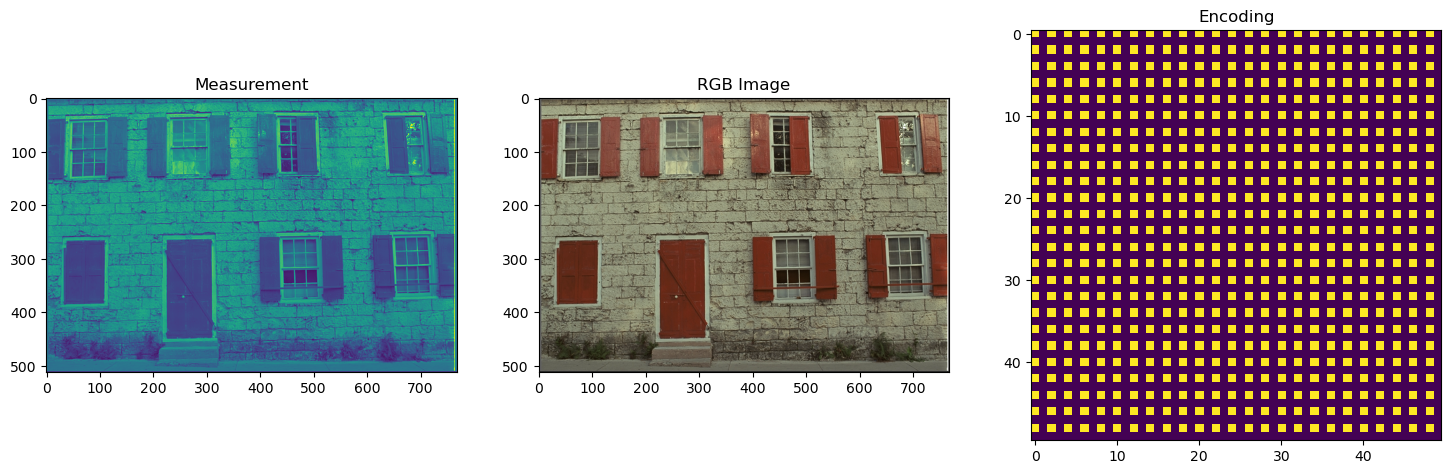

In [372]:
C = 3
B = np.zeros((2,2,C))
B[0,0,0] = 1
B[1,1,2] = 1
B[0,1,1] = 1
B[1,0,1] = 1
#M, N= img.size
[M,N,L] = np.shape(img)
print(M,N)
T = np.zeros((M,N,C))
Y = np.zeros((M,N))
I = np.ones((M//2,N//2))
In= np.array(img)
#img.show()
for c in range(C):
    T[:,:,c] = np.kron(I,B[:,:,c])
    Y = Y + T[:,:,c]*In[:,:,c]
fig, axes = plt.subplots(1,3, figsize=(18,6))
axes[0].imshow(Y[:,:])
axes[0].set_title("Measurement")
axes[1].imshow(In/255, vmin=0, vmax=1)
axes[1].set_title("RGB Image")
axes[2].imshow(T[0:50,0:50,0], vmin=0, vmax=1)
axes[2].set_title("Encoding")

### Demosaicking

120.88142178215328 0.2981714771809007
uint8


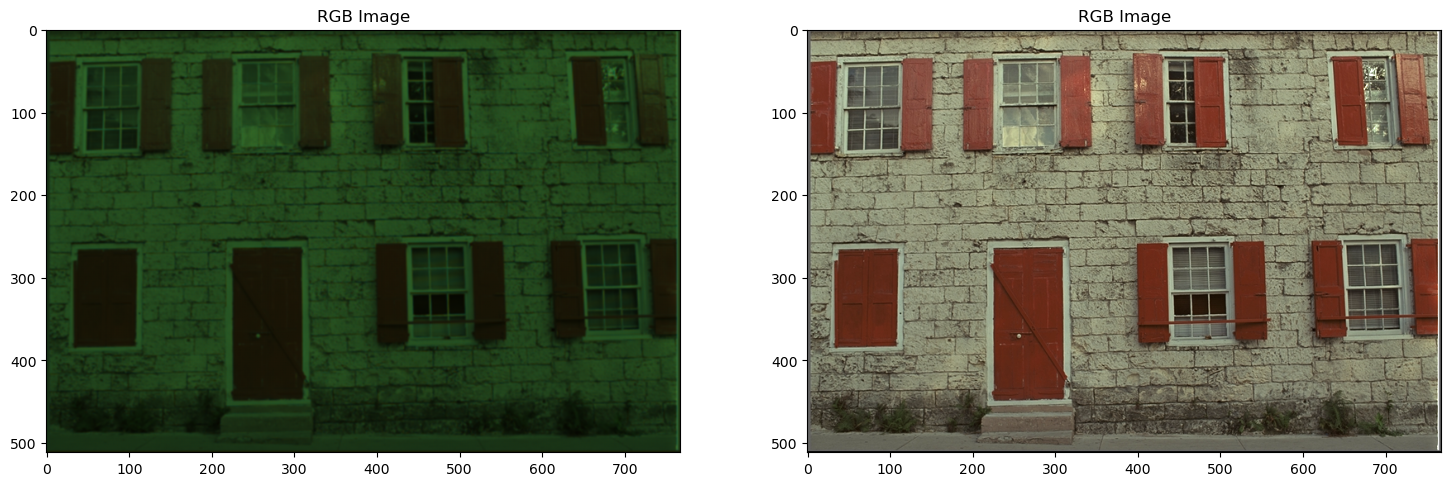

In [ ]:
It = np.zeros((M,N,C))
Ir = np.zeros((M,N,C),float)

def fspecial_gaussian(hsize=3, sigma=0.5):
    # Accept scalar size or [rows, cols] tuple
    if isinstance(hsize, (int, float)):
        hsize = [int(hsize), int(hsize)]
    
    # Calculate grid bounds matching MATLAB behavior
    bounds_y = [(i - (hsize[0] - 1) / 2.0) for i in range(hsize[0])]
    bounds_x = [(i - (hsize[1] - 1) / 2.0) for i in range(hsize[1])]
    y, x = np.meshgrid(bounds_y, bounds_x, indexing='ij')
    
    # Compute the Gaussian distribution
    arg = -(x**2 + y**2) / (2.0 * sigma**2)
    h = np.exp(arg)
    
    # Apply MATLAB's epsilon thresholding to clip near-zero values
    h[h < np.finfo(h.dtype).eps * h.max()] = 0
    
    # Normalize the filter weights to sum to 1
    sumh = h.sum()
    if sumh != 0:
        h /= sumh
    return h


def fspecial_laplacian(alpha=0.2):
    # Shape parameter alpha must be between 0 and 1
    alpha = max(0.0, min(1.0, alpha))
    h = np.array([[alpha,   1.0-alpha, alpha],
                  [1.0-alpha, -4.0,     1.0-alpha],
                  [alpha,   1.0-alpha, alpha]], dtype=np.float64)
    # Scale based on alpha parameter
    h /= (alpha + 1.0)
    return h
kernel = fspecial_laplacian()
kernel = np.ones((3, 3)) / 9.0
kernel = np.ones((3,3,3))
kernel[:,:,0] = kernel[:,:,0]*1/4
kernel[:,:,1] = kernel[:,:,0]*1/2
kernel[:,:,2] = kernel[:,:,0]*1/4
# Example Usage:
kernel = fspecial_gaussian(hsize=5, sigma=1.0)
for c in range(C):
    It[:,:,c] = T[:,:,c]*Y
    Ir[:,:,c] = ndimage.correlate(It[:,:,c], kernel, mode='mirror')

print(np.max(Ir),np.min(Ir))
Ir = np.uint8(abs(Ir))
fig, axes = plt.subplots(1,2, figsize=(18,6))
axes[0].imshow(Ir/255, vmin=0, vmax=1)
axes[0].set_title("RGB Image")
axes[1].imshow(In/255, vmin=0, vmax=1)
axes[1].set_title("RGB Image")
p = psnr(In,Ir)
#s,diff = ssim(In,Ir, data_range=255, full=True)
print(In.dtype)